In [ ]:
# ==========================================
#Assignment 3 (Text Sentiment Classification using RNN & LSTM)
#NAME: Yashvant Giri
#Roll Number: 2501940053
#Course Code & Title: Deep Learning Architectures and Techniques(ETMMDL274)
#MCA(AI&ML)
# ==========================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report

In [2]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

In [3]:
max_len = 200

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)
print(x_train[0])

[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  113  103   32   15   16
 5345 

In [4]:
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_rnn = rnn_model.fit(x_train, y_train, epochs=5, validation_split=0.2)

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 151ms/step - accuracy: 0.6718 - loss: 0.5986 - val_accuracy: 0.6640 - val_loss: 0.6024
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 140ms/step - accuracy: 0.8142 - loss: 0.4218 - val_accuracy: 0.7560 - val_loss: 0.5780
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 116ms/step - accuracy: 0.9071 - loss: 0.2319 - val_accuracy: 0.6540 - val_loss: 0.8280
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.9631 - loss: 0.1010 - val_accuracy: 0.7756 - val_loss: 0.7038
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 128ms/step - accuracy: 0.9889 - loss: 0.0377 - val_accuracy: 0.7432 - val_loss: 0.9291


In [5]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = lstm_model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 232ms/step - accuracy: 0.7915 - loss: 0.4482 - val_accuracy: 0.8462 - val_loss: 0.3661
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 201ms/step - accuracy: 0.8936 - loss: 0.2753 - val_accuracy: 0.8664 - val_loss: 0.3444
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.9243 - loss: 0.1981 - val_accuracy: 0.8476 - val_loss: 0.3658
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 220ms/step - accuracy: 0.9485 - loss: 0.1421 - val_accuracy: 0.8714 - val_loss: 0.4154
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 223ms/step - accuracy: 0.9665 - loss: 0.0956 - val_accuracy: 0.8464 - val_loss: 0.4509


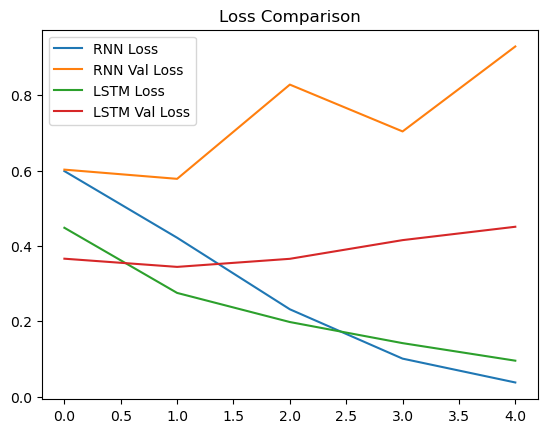

In [6]:
plt.plot(history_rnn.history['loss'], label='RNN Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Val Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.legend()
plt.title("Loss Comparison")
plt.show()

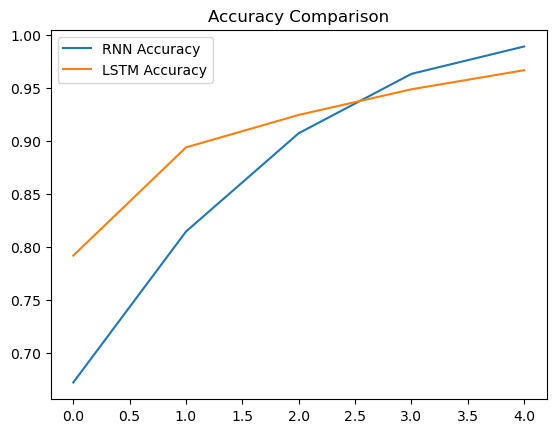

In [7]:
plt.plot(history_rnn.history['accuracy'], label='RNN Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Accuracy')
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

In [8]:
y_pred = (lstm_model.predict(x_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 74ms/step
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     12500
           1       0.83      0.87      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000

